In [1]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
#from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm
import xesmf as xe
import glob

<xarray.Dataset> Size: 20MB
Dimensions:  (lon: 360, lat: 91, year: 76)
Coordinates:
  * lon      (lon) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0
  * lat      (lat) float64 728B 0.0 -1.0 -2.0 -3.0 ... -87.0 -88.0 -89.0 -90.0
  * year     (year) int64 608B 1950 1951 1952 1953 1954 ... 2022 2023 2024 2025
Data variables:
    psi      (year, lat, lon) float64 20MB 0.1021 0.1021 ... -0.7769 -0.7769

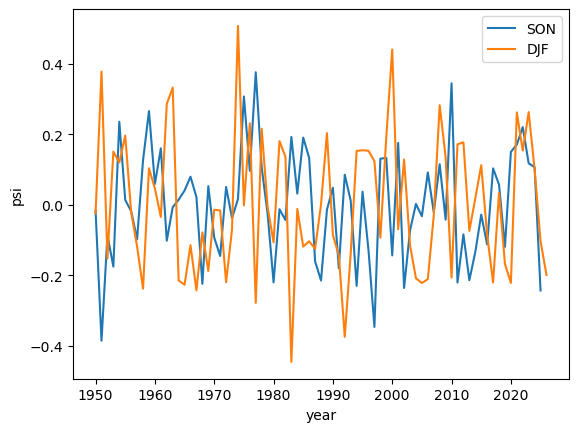

In [2]:
psi_SON=xr.open_dataset('ERA5_dyn_data_ready/psi500_SON.nc')
psi_SON=psi_SON.rename({'latitude': 'lat', 'longitude': 'lon'})
psi_SON['psi'].mean(dim=['lat', 'lon']).plot()
plt.title('Mean 500 hPa streamfunction')

display(psi_SON)

psi_DJF=xr.open_dataset('ERA5_dyn_data_ready/psi500_DJF.nc')
psi_DJF=psi_DJF.rename({'latitude': 'lat', 'longitude': 'lon'})
psi_DJF['psi'].mean(dim=['lat', 'lon']).plot()
plt.legend(['SON', 'DJF'])

In [3]:
##import psi_climatologies here
psi_clim_SON=xr.open_dataset('ERA5_dyn_data_ready/psi500_climatology_SON.nc')
psi_clim_SON=psi_clim_SON.rename({'latitude': 'lat', 'longitude': 'lon'})
psi_clim_DJF=xr.open_dataset('ERA5_dyn_data_ready/psi500_climatology_DJF.nc')
psi_clim_DJF=psi_clim_DJF.rename({'latitude': 'lat', 'longitude': 'lon'})

psi_clim_SON=psi_clim_SON.rename_vars({'__xarray_dataarray_variable__': 'psi'})
psi_clim_DJF=psi_clim_DJF.rename_vars({'__xarray_dataarray_variable__': 'psi'})

print(psi_clim_SON.dims)
#seasonal average and standardise again
def avg_time_year(da):
    da_season=da.groupby("time.year").mean("time")
    da_all_years=da_season.groupby("year").mean("year")
    return da_all_years
psi_all_years_SON=avg_time_year(psi_clim_SON)
psi_all_years_DJF=avg_time_year(psi_clim_DJF)

FrozenMappingWarningOnValuesAccess({'lon': 360, 'lat': 91, 'time': 6916})


In [4]:
display(psi_all_years_SON)

<xarray.Dataset> Size: 10MB
Dimensions:  (year: 76, lat: 91, lon: 360)
Coordinates:
  * lon      (lon) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0
  * lat      (lat) float64 728B 0.0 -1.0 -2.0 -3.0 ... -87.0 -88.0 -89.0 -90.0
  * year     (year) int64 608B 1950 1951 1952 1953 1954 ... 2022 2023 2024 2025
Data variables:
    psi      (year, lat, lon) float32 10MB -5.491e+05 -5.491e+05 ... -2.598e+06

In [5]:
lon_axis_clm = psi_SON.dims
print(lon_axis_clm)


FrozenMappingWarningOnValuesAccess({'lon': 360, 'lat': 91, 'year': 76})


In [6]:
def c_diff(arr, h, dim, cyclic = False):  #compute derivate of array variable respect to h associated to dim
    #adapted from kuchaale script
    ndim = arr.ndim
    lst = [i for i in range(ndim)]

    lst[dim], lst[0] = lst[0], lst[dim]
    rank = lst 
    
    arr = np.transpose(arr, tuple(rank))
    print(arr.shape)
    if ndim == 3:
        #shp = (arr.shape[0]-2,1,1)
        shp = (arr.shape[dim]-2,) + (1,)*(arr.ndim-1)
        print(shp)
    elif ndim == 4:
        shp = (arr.shape[0]-2,1,1,1)
    
    d_arr = np.copy(arr)
    if not cyclic:  
        d_arr[0,...] = (arr[1,...]-arr[0,...])/(h[1]-h[0])
        d_arr[-1,...] = (arr[-1,...]-arr[-2,...])/(h[-1]-h[-2])
        d_arr[1:-1,...] = (arr[2:,...]-arr[0:-2,...])/np.reshape(h[2:]-h[0:-2], shp)

    elif cyclic:
        d_arr[0,...] = (arr[1,...]-arr[-1,...])/(h[1]-h[-1])
        d_arr[-1,...] = (arr[0,...]-arr[-2,...])/(h[0]-h[-2])
        d_arr[1:-1,...] = (arr[2:,...]-arr[0:-2,...])/np.reshape(h[2:]-h[0:-2], shp)

    d_arr = np.transpose(d_arr, tuple(rank))

    return d_arr

def WAF_computation(psiclm, psiaa):

    lat=psiaa['lat'].values
    lon=psiaa['lon'].values
    nlats = len(lat)
    nlons = len(lon)

    psiclm_x=psiclm.values
    psiaa_x=psiaa.values

    #earth radius
    a = 6400000
    
    coslat = np.cos(lat*3.14/180)
    
    #climatological wind at psi level using climatological streamfunction
    
    dpsiclmdlon = c_diff(psiclm_x,lon,0, cyclic=True)
    
    dpsiclmdlat = c_diff(psiclm_x,lat,1)
    
    uclm = -1*dpsiclmdlat
    
    vclm = dpsiclmdlon
    
    magU = np.sqrt(np.add(np.power(uclm,2),np.power(vclm,2)))
    
    #derivatives of psi anomaly
    dpsidlon = c_diff(psiaa_x,lon,0, cyclic=True)
    
    ddpsidlonlon = c_diff(dpsidlon,lon,0, cyclic=True)
    
    dpsidlat = c_diff(psiaa_x,lat,1)
    ddpsidlatlat = c_diff(dpsidlat,lat,1)
    
    ddpsidlatlon = c_diff(dpsidlat,lon,0, cyclic=True)
    
    termxu = dpsidlon*dpsidlon-psiaa_x*ddpsidlonlon
    
    termxv = dpsidlon*dpsidlat-ddpsidlatlon*psiaa_x
    
    termyv = dpsidlat*dpsidlat-psiaa_x*ddpsidlatlat
    
    # 0.2101 is the scale of p
    coeff1 = np.transpose(np.tile(coslat,(nlons,1)))*(0.2101)/(2*magU)
    
    #x-component
    px = coeff1/(a*a*np.transpose(np.tile(coslat,(nlons,1))))*( uclm*termxu/np.transpose(np.tile(coslat,(nlons,1))) + vclm*termxv)
    
    #y-component
    py = coeff1/(a*a)*( uclm/np.transpose(np.tile(coslat,(nlons,1)))*termxv + vclm*termyv)

In [7]:
def spatial_derivatives(psi):
    """
    Compute zonal and meridional gradients safely.
    Assumes psi dims: (..., lat, lon)
    """

    dpsidy = psi.differentiate("lat")   # ∂ψ/∂y
    dpsidx = psi.differentiate("lon")   # ∂ψ/∂x

    return dpsidx, dpsidy

def WAF_computation(psi_clim, psi_anom):
    
    # Earth radius
    a = 6.371e6

    lat = psi_clim["lat"]
    lon = psi_clim["lon"]

    coslat = np.cos(np.deg2rad(lat))

    # --- CLIMATOLOGICAL WIND FROM STREAMFUNCTION ---
    dpsidx_clim, dpsidy_clim = spatial_derivatives(psi_clim)

    uclm = -dpsidy_clim
    vclm = dpsidx_clim

    magU = np.sqrt(uclm**2 + vclm**2)
    magU = magU.where(magU != 0)  # avoid division by zero

    # --- ANOMALY DERIVATIVES ---
    dpsidx, dpsidy = spatial_derivatives(psi_anom)

    d2psidx2 = dpsidx.differentiate("lon")
    d2psidy2 = dpsidy.differentiate("lat")
    d2psidxy = dpsidy.differentiate("lon")

    # --- TAYLOR / WAF TERMS ---
    term_xu = dpsidx**2 - psi_anom * d2psidx2
    term_xv = dpsidx * dpsidy - psi_anom * d2psidxy
    term_yv = dpsidy**2 - psi_anom * d2psidy2

    # --- GEOMETRY FACTORS ---
    coslat_2d = coslat.broadcast_like(psi_clim)

    a2 = a**2
    #scaling factor for p=0.2101
    prefactor = (0.2101 * coslat_2d) / (2 * magU)

    # --- WAF COMPONENTS ---
    px = (prefactor / (a2*coslat_2d) ) * (
        uclm * term_xu / coslat_2d + vclm * term_xv
    )

    py = (prefactor / a2) * (
        uclm / coslat_2d * term_xv + vclm * term_yv
    )

    return xr.Dataset({"WAF_x": px, "WAF_y": py})

In [8]:
WAF_SON=WAF_computation(psi_all_years_SON['psi'], psi_SON['psi'])
print(WAF_SON)
WAF_DJF=WAF_computation(psi_all_years_DJF['psi'], psi_DJF['psi'])
print(WAF_DJF)

<xarray.Dataset> Size: 40MB
Dimensions:  (lat: 91, year: 76, lon: 360)
Coordinates:
  * lat      (lat) float64 728B 0.0 -1.0 -2.0 -3.0 ... -87.0 -88.0 -89.0 -90.0
  * year     (year) int64 608B 1950 1951 1952 1953 1954 ... 2022 2023 2024 2025
  * lon      (lon) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0
Data variables:
    WAF_x    (year, lat, lon) float64 20MB -3.678e-24 7.45e-25 ... 7.012e-08
    WAF_y    (year, lat, lon) float64 20MB -7.33e-20 -7.394e-20 ... 1.432e-18
<xarray.Dataset> Size: 40MB
Dimensions:  (lat: 91, year: 76, lon: 360)
Coordinates:
  * lat      (lat) float64 728B 0.0 -1.0 -2.0 -3.0 ... -87.0 -88.0 -89.0 -90.0
  * year     (year) int64 608B 1950 1951 1952 1953 1954 ... 2022 2023 2024 2025
  * lon      (lon) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0
Data variables:
    WAF_x    (year, lat, lon) float64 20MB 1.459e-24 -1.851e-23 ... 3.045e-07
    WAF_y    (year, lat, lon) float64 20MB -2.985e-19 -3.018e-19 ... -2.932e-19


In [9]:

years_to_drop = [1950, 2002, 2019, 2025]

def exclude_years_xr(xr_obj, years):
    return xr_obj.sel(year=~xr_obj.year.isin(years))

psi_SON=exclude_years_xr(psi_SON, years_to_drop)
WAF_SON=exclude_years_xr(WAF_SON, years_to_drop)
cut_years=[1950,2003,2020,2025]
psi_DJF=exclude_years_xr(psi_DJF, cut_years)
WAF_DJF=exclude_years_xr(WAF_DJF, cut_years)

In [12]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('data_ready/7.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

In [13]:
##SON data
ds_SON = xr.merge([psi_SON, WAF_SON, era_SON_LaPlata_array])

##DJF data
ds_DJF=xr.merge([psi_DJF, WAF_DJF, era_DJF_LaPlata_array])

Regressions and Maps

In [14]:
def lin_model_fast(y, x_main, *x_controls):
    """
    y         : (window,)
    x_main    : (window,)
    x_controls: (window,)

    Returns
    -------
    coef_main : float
    """

    # stack predictors
    X_list = [x_main] + list(x_controls)
    X = np.stack(X_list, axis=1)  # shape (window, n_predictors)

    # remove NaNs
    mask = ~np.any(np.isnan(X), axis=1) & ~np.isnan(y)
    if mask.sum() < X.shape[1]:  # not enough data
        return np.nan

    X = X[mask]
    y = y[mask]

    try:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        return beta[0]  # coefficient of main predictor
    except np.linalg.LinAlgError:
        return np.nan
import xarray as xr

def sensitivity_analysis_fast(ds_rolled, target, driver, controls=None):
    """
    Perform regression for each grid point and rolling window.

    Parameters
    ----------
    ds_rolled : Dataset (year, window, lat, lon)
    target    : str (e.g. 't2m')
    driver    : str (main predictor, e.g. 'ENSO')
    controls  : list of str (optional)

    Returns
    -------
    coef_da : DataArray (year, lat, lon)
    """

    y = ds_rolled[target]
    x_main = ds_rolled[driver]

    if controls is not None:
        x_controls = [ds_rolled[var] for var in controls]
    else:
        x_controls = []

    coef = xr.apply_ufunc(
        lin_model_fast,
        y,
        x_main,
        *x_controls,
        input_core_dims=[["window"]] * (2 + len(x_controls)),
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    return coef


def conditioning_everything_fast(ds, driver_list, target, total_eff=False):
    """
    Compute regression maps for multiple drivers.

    Returns
    -------
    list of DataArrays (one per driver)
    """

    results = []

    # create rolling windows once
    ds_rolled = ds #construct_da_x_year_fix(ds)

    for driver in driver_list:

        # determine controls
        if not total_eff:
            controls = [d for d in driver_list if d != driver]

            if 'A_SAM' in driver_list and driver in ['SPV', 'VB', 'S_SAM']:
                if 'A_SAM' in controls:
                    controls.remove('A_SAM')

            elif ('SPV' in driver_list or 'VB' in driver_list) and driver == 'A_SAM':
                controls = [c for c in controls if c not in ['SPV', 'VB', 'S_SAM']]

        else:
            if driver == 'IOD' or driver=='IOBW':
                controls = ['ENSO']
            elif driver == 'SPV':
                controls = ['ENSO', 'IOD']
            elif driver == 'VB':
                controls = ['ENSO', 'IOBW']
            else:
                controls = None

        coef = sensitivity_analysis_fast(
            ds_rolled,
            target=target,
            driver=driver,
            controls=controls
        )

        mean_coef = coef.mean(dim="year")

        results.append(mean_coef)

        print(f"{driver} done")

    return results

In [ ]:
import cartopy.feature as cfeature

def modified_colorbar(cmap, levels, center_zero=True):
    n = len(levels) - 1
    colors = cmap(np.linspace(0, 1, n))
    
    if center_zero:
        mid = n // 2
        if n % 2 == 0: ##for even number of levels, set the two middle colors to white
            colors[mid-1:mid+1] = [1, 1, 1, 1]
        else:
            colors[mid] = np.array([1, 1, 1, 1])  # white
    
    return mcolors.ListedColormap(colors)

def plot_map(
    i,
    da,
    title,
    units,
    fig,
    subplts_num,
    cmap=plt.cm.viridis,
    WAF=None,
    cbar_each=None,
    levels=None,
    pval=None,
    fontsize=14,
    smooth=False,
):
    """
    Plot a regional map using only the spatial extent of da with PlateCarree.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with dimensions (lat, lon)
    pval : xarray.DataArray, optional
        p-values on same grid as da
    """
    # Extract coordinates
    lat = da.lat.values
    lon = da.lon.values
    arr = da.values

    # Create axis with PlateCarree projection
    ax = fig.add_subplot(1, subplts_num, i, projection=ccrs.PlateCarree())

    # Set extent to data region only
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Colormap normalization
    # ---- FIX: always center at zero ----
    if cbar_each is None:
        vmax = np.nanmax(np.abs(arr))
    else:
        vmax=cbar_each
    levels = np.arange(-2, 2.01, 0.5)  # include +2
    #modify colorbar
    cmap_mod = modified_colorbar(cmap, levels, center_zero=True)
    norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

    # Plot the field
    if smooth:
        cs = ax.contourf(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(), cmap=cmap_mod)
    else:
        cs = ax.pcolormesh(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(),
                           cmap=cmap_mod, shading="auto")

    ax.coastlines(resolution="50m")        # still keep coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)  # add country borders

    # Title
    ax.text(0.01, 1.02, title, transform=ax.transAxes, fontsize=fontsize)
    ax.set_adjustable('box')

    # Colorbar
    # ---- individual colorbars ----
    if cbar_each is None:
        cbar_ax = ax.inset_axes([0.05, -0.12, 0.9, 0.07])
        cbar = plt.colorbar(cs, orientation="horizontal", cax=cbar_ax,fraction=0.046,
                pad=0.08)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(units, fontsize=fontsize)

    # Significance overlay
    if pval is not None:
        inds = np.argwhere(pval.values > 0.05)
        ax.plot(
            lon[inds[:, 1]],
            lat[inds[:, 0]],
            markersize=5.0,
            color="grey",
            marker=".",
            linestyle="None",
            transform=ccrs.PlateCarree(),
        )
    ##add WAF vectors if provided
    if WAF is not None:
        px = WAF['WAF_x'].values
        py = WAF['WAF_y'].values
        lon = WAF['WAF_x']['lon'].values
        lat = WAF['WAF_x']['lat'].values
        
        ##for quiver too work, need 2d lat and lon arrays
        lon2d, lat2d = np.meshgrid(lon, lat)

        #plot plumb fluxes and save again
        #mask wind data to only show the 20% stronger fluxes.
        Q80=np.percentile(np.sqrt(np.add(np.power(px,2),np.power(py,2))),90) 
        M = np.sqrt(np.add(np.power(px,2),np.power(py,2))) < Q80
        #mask array
        px_mask = np.ma.array(px,mask = M)
        py_mask = np.ma.array(py,mask = M)
        #plot vectors
        ax.quiver(lon2d[2:-1:2,2:-1:2], lat2d[2:-1:2,2:-1:2], px_mask[2:-1:2, 2:-1:2],\
                  py_mask[2:-1:2, 2:-1:2], width=1e-3, headwidth=3,#headwidht (default3)
                        headlength=2.2, transform=ccrs.PlateCarree())  # (default5))	      
    
    return cs

        
def subplots_map(ds, title_list, cmap=plt.cm.coolwarm, unit='K', cbar_each=None, heading=None):
    cs_list=[]
    fontsize=16
    global_max=0
    for da in ds:
        local_max = np.nanmax(np.abs(da.values))
        global_max = max(global_max, local_max)
        
    ##Find optimal figsize
    width_per_plot = 4
    height = 5 

    fig = plt.figure(figsize=(len(ds) * width_per_plot, height))
    fig.subplots_adjust(top=0.8)
    
    for j, da in enumerate(ds):
        
        cs=plot_map( #get the colorbar for each subplot
        i=j+1,
        da=da,
        pval=None,
        title=title_list[j],
        units=unit,
        cbar_each=global_max,
        fig=fig,
        subplts_num=len(ds),
        cmap=cmap,
        smooth=False,
        fontsize=fontsize)
        
        cs_list.append(cs)
    
    plt.tight_layout(rect=[0, 0.12, 1, 0.92])
    
    levels = np.linspace(-global_max, global_max, 7)  
    # → 10 color bins (adjust as you like)
    
    if not cbar_each:
        # create independent global norm
        levels = np.arange(-2, 2.01, 0.2)  # include +2
        global_norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

        sm = cm.ScalarMappable(norm=global_norm, cmap=cmap)
        sm.set_array([])
        
        cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(unit, fontsize=fontsize)
        
    ##Heading
    if heading:
        fig.suptitle(heading, y=1.1, fontweight='bold', fontsize=18)
        fig.savefig('maps/'+heading+'.jpg', dpi=300, bbox_inches='tight')
    
    plt.show()

In [16]:
def fast_comp_prep(da):
    da_rolled = da.rolling(year=30, center=False).construct("window")
    da_rolled = da_rolled.isel(year=slice(29, None)) # drop incomplete windows
    da_chunk=da_rolled.chunk(lon=330, lat=20, year=-1)
    return da_chunk

In [17]:
psi500_chunked_SON=fast_comp_prep(ds_SON)
psi500_chunked_DJF=fast_comp_prep(ds_DJF)
display(psi500_chunked_SON.sel(year=1981))
#display(psi500_30_years_SON.isel(window=21, lat=-20, lon=-20, year=10))

<xarray.Dataset> Size: 24MB
Dimensions:         (lon: 360, lat: 91, window: 30)
Coordinates:
  * lon             (lon) float64 3kB -180.0 -179.0 -178.0 ... 177.0 178.0 179.0
  * lat             (lat) float64 728B 0.0 -1.0 -2.0 -3.0 ... -88.0 -89.0 -90.0
    year            int64 8B 1981
Dimensions without coordinates: window
Data variables: (12/13)
    psi             (lat, lon, window) float64 8MB dask.array<chunksize=(20, 330, 30), meta=np.ndarray>
    WAF_x           (lat, lon, window) float64 8MB dask.array<chunksize=(20, 330, 30), meta=np.ndarray>
    WAF_y           (lat, lon, window) float64 8MB dask.array<chunksize=(20, 330, 30), meta=np.ndarray>
    t_LaPlata       (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    precip_LaPlata  (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    ENSO            (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    ...              ...
    EDJ             (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    EDJ_lat         (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    EDJ_lat_nostd   (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    SPV             (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    A_SAM           (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    S_SAM           (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>

In [18]:
def compute_reg_for_vars(ds, driver_list, target_list):
    target_dict={}
    for target in target_list:
        result=conditioning_everything_fast(ds, driver_list, target)
        result_comp=[m.compute() for m in result]
        target_dict[target] = result_comp
    return target_dict

In [19]:
psi500_all=conditioning_everything_fast(psi500_chunked_SON, ['ENSO','IOD','SPV', 'S_SAM','A_SAM'], 'psi')
psi500_all_comp=[m.compute() for m in psi500_all]
WAF_x500_all=conditioning_everything_fast(psi500_chunked_SON, ['ENSO','IOD','SPV', 'S_SAM','A_SAM'], 'WAF_x')
WAF_x500_all_comp=[m.compute() for m in WAF_x500_all]
WAF_y500_all=conditioning_everything_fast(psi500_chunked_SON, ['ENSO','IOD','SPV', 'S_SAM','A_SAM'], 'WAF_y')
WAF_y500_all_comp=[m.compute() for m in WAF_y500_all]

ENSO done
IOD done
SPV done
S_SAM done
A_SAM done
ENSO done
IOD done
SPV done
S_SAM done
A_SAM done
ENSO done
IOD done
SPV done
S_SAM done
A_SAM done


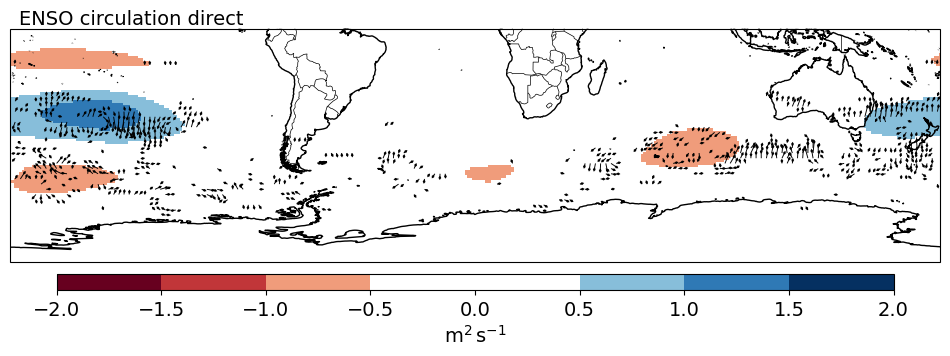

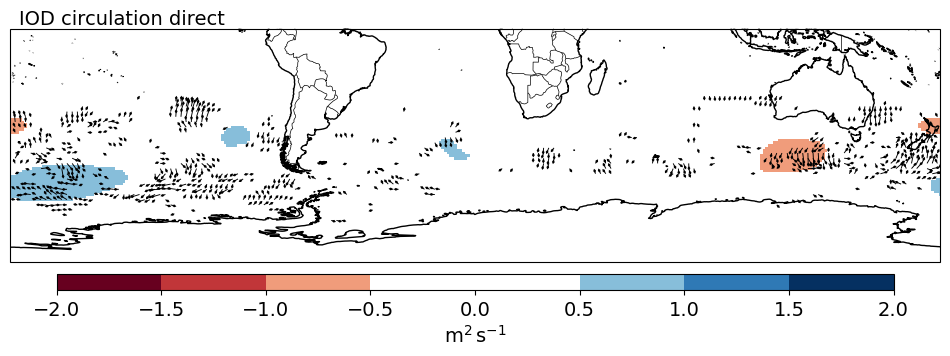

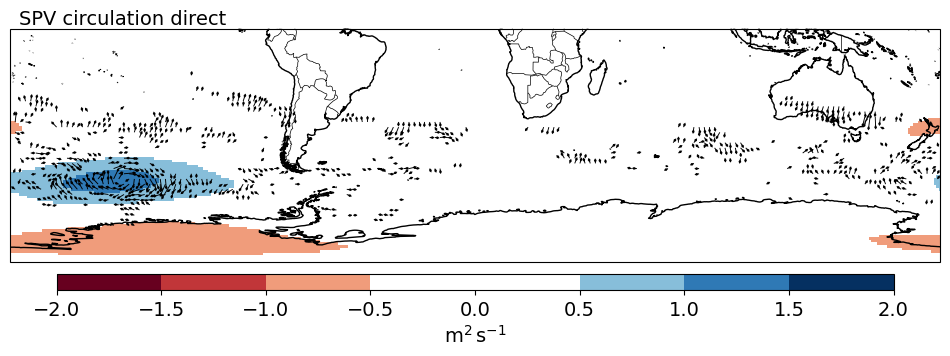

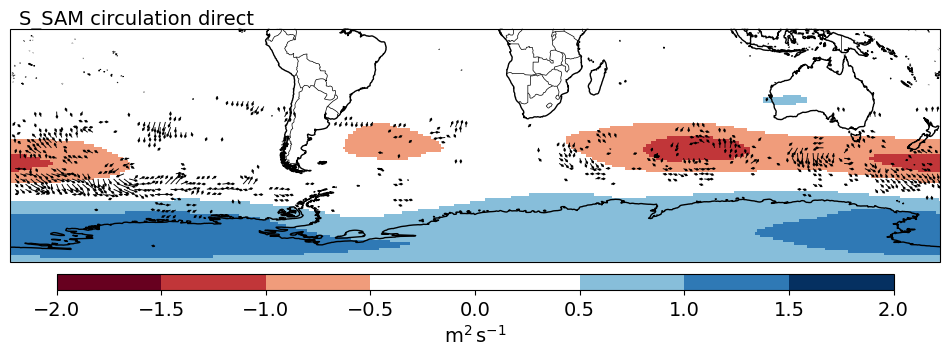

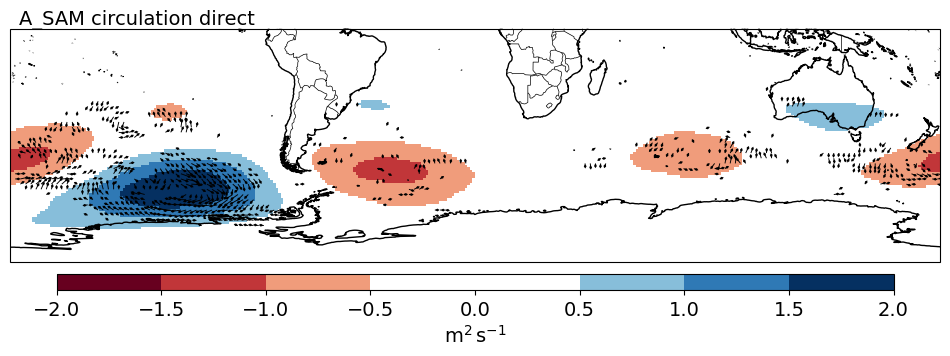

In [31]:
plot_map(1, psi500_all_comp[0], 'ENSO circulation direct', '$\mathrm{m^2\,s^{-1}}$', plt.figure(figsize=(12,7)), \
         1, cmap=plt.cm.RdBu, WAF={'WAF_x': WAF_x500_all_comp[0], 'WAF_y': WAF_y500_all_comp[0]})
plt.savefig('regression_maps_psi500/ENSO_PSI500_direct_SON.jpg')
plot_map(1, psi500_all_comp[1], 'IOD circulation direct', '$\mathrm{m^2\,s^{-1}}$', plt.figure(figsize=(12,7)), \
         1, cmap=plt.cm.RdBu, WAF={'WAF_x': WAF_x500_all_comp[1], 'WAF_y': WAF_y500_all_comp[1]})
plt.savefig('regression_maps_psi500/IOD_PSI500_direct_SON.jpg')

plot_map(1, psi500_all_comp[2], 'SPV circulation direct', '$\mathrm{m^2\,s^{-1}}$', plt.figure(figsize=(12,7)), \
         1, cmap=plt.cm.RdBu, WAF={'WAF_x': WAF_x500_all_comp[2], 'WAF_y': WAF_y500_all_comp[2]})
plt.savefig('regression_maps_psi500/SPV_PSI500_direct_SON.jpg')

plot_map(1, psi500_all_comp[3], 'S_SAM circulation direct', '$\mathrm{m^2\,s^{-1}}$', plt.figure(figsize=(12,7)), \
         1, cmap=plt.cm.RdBu, WAF={'WAF_x': WAF_x500_all_comp[3], 'WAF_y': WAF_y500_all_comp[3]})
plt.savefig('regression_maps_psi500/S_SAM_PSI500_direct_SON.jpg')

plot_map(1, psi500_all_comp[len(psi500_all_comp)-1], 'A_SAM circulation direct', '$\mathrm{m^2\,s^{-1}}$', plt.figure(figsize=(12,7 )), \
         1, cmap=plt.cm.RdBu, WAF={'WAF_x': WAF_x500_all_comp[len(psi500_all_comp)-1], 'WAF_y': WAF_y500_all_comp[len(psi500_all_comp)-1]})
plt.savefig('regression_maps_psi500/A_SAM_PSI500_direct_SON.jpg')

In [ ]:
#subplots_map(u850_all_comp, ['ENSO','IOD','SPV', 'S_SAM','A_SAM'], cmap=plt.cm.coolwarm, unit='$\mathrm{m\,s^{-1}}$', heading='U850 SON')

In [29]:
IOD_SON_no_cond=compute_reg_for_vars(psi500_chunked_SON, ['IOD'], ['psi', 'WAF_x', 'WAF_y'])

IOD done
IOD done
IOD done


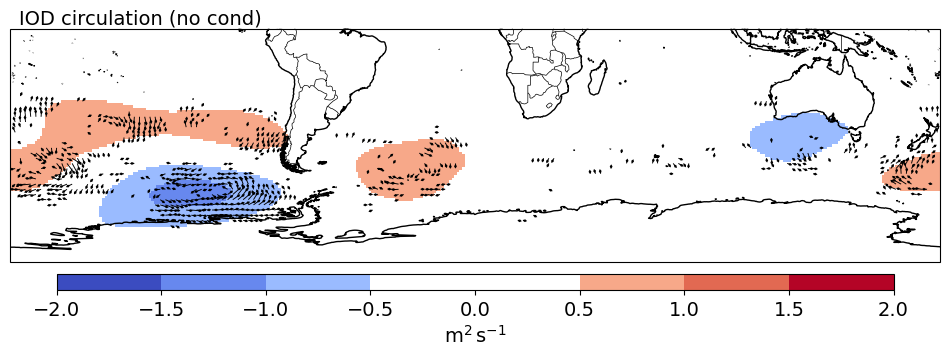

In [32]:
plot_map(1, IOD_SON_no_cond['psi'][0], 'IOD circulation (no cond)', '$\mathrm{m^2\,s^{-1}}$', plt.figure(figsize=(12,7)), \
         1, cmap=plt.cm.coolwarm, WAF={'WAF_x': IOD_SON_no_cond['WAF_x'][0], 'WAF_y': IOD_SON_no_cond['WAF_y'][0]})
plt.savefig('regression_maps_psi500/IOD_PSI500_nocond_SON.jpg')
